<a href="https://colab.research.google.com/github/kadiwala1234/Project-Image-Classification/blob/main/Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Image Classification Using Random Forest and SVM**

In [1]:
# 1. Dataset Selection & Preprocessing
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

In [2]:
# Load & Preprocess Images

from google.colab import files
uploaded = files.upload()

Saving images.zip to images.zip


In [3]:
import zipfile

with zipfile.ZipFile("images.zip", 'r') as zip_ref:
    zip_ref.extractall("images")

In [4]:
print(os.listdir("images"))

['pizza', 'soccer_ball', 'dalmatian', 'dollar_bill', 'sunflower']


In [5]:
IMG_SIZE = 64  # you can try 32, 64, or 128

data = []
labels = []

dataset_path = "/content/images"

class_names = os.listdir(dataset_path)

for label in class_names:
    class_path = os.path.join(dataset_path, label)

    for img_name in os.listdir(class_path):
        try:
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            data.append(img.flatten())  # flatten for ML models
            labels.append(label)
        except:
            pass

X = np.array(data) / 255.0   # normalization
y = np.array(labels)

In [6]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
# Random Forest Model Training
# Hyperparameter Grid
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [8]:
# Grid Search / Training

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [9]:
# Model Evaluation
# Predictions

y_pred = best_model.predict(X_test)

In [11]:
# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7741935483870968
              precision    recall  f1-score   support

   dalmatian       0.77      0.71      0.74        14
 dollar_bill       0.80      0.80      0.80        10
       pizza       0.62      0.50      0.56        10
 soccer_ball       0.82      0.82      0.82        11
   sunflower       0.80      0.94      0.86        17

    accuracy                           0.77        62
   macro avg       0.76      0.75      0.76        62
weighted avg       0.77      0.77      0.77        62



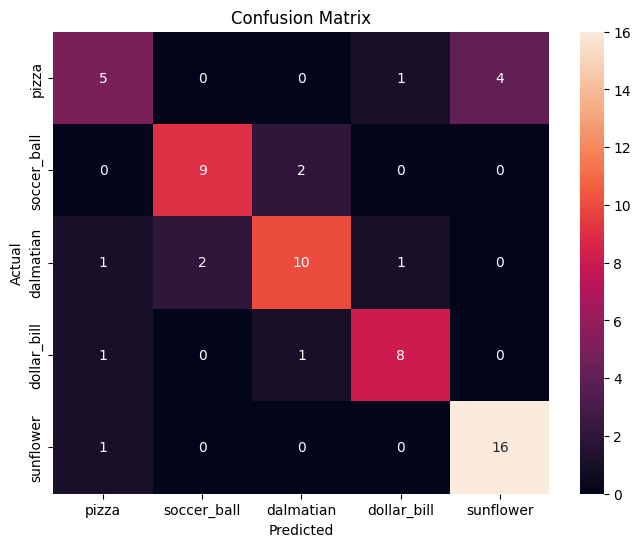

In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=class_names)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

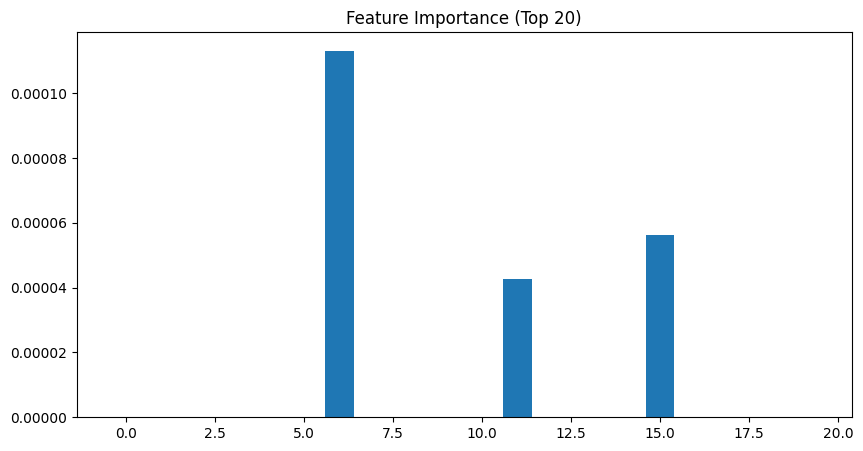

In [13]:
# Feature Importance

importances = best_model.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(range(len(importances[:20])), importances[:20])  # show top 20 features
plt.title("Feature Importance (Top 20)")
plt.show()

In [16]:
# Predict New Image
def predict_image(img_path, model):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.flatten().reshape(1, -1) / 255.0

    pred = model.predict(img)
    return pred[0]

In [19]:
from google.colab import files
uploaded = files.upload()

Saving image_0002.jpg to image_0002.jpg


In [21]:
# Test it
print(predict_image(r"image_0002.jpg", best_model))

sunflower


In [22]:
# Bonus: SVM Model
# Train SVM

svm = SVC()

svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

svm_grid = GridSearchCV(svm, svm_params, cv=3, n_jobs=-1)
svm_grid.fit(X_train, y_train)

svm_best = svm_grid.best_estimator_

In [23]:
# Evaluate SVM
svm_pred = svm_best.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.8548387096774194
              precision    recall  f1-score   support

   dalmatian       0.93      0.93      0.93        14
 dollar_bill       0.75      0.90      0.82        10
       pizza       0.73      0.80      0.76        10
 soccer_ball       0.89      0.73      0.80        11
   sunflower       0.94      0.88      0.91        17

    accuracy                           0.85        62
   macro avg       0.85      0.85      0.84        62
weighted avg       0.86      0.85      0.86        62



In [24]:
# Comparison (RF vs SVM)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

Random Forest Accuracy: 0.7741935483870968
SVM Accuracy: 0.8548387096774194


In [25]:
import joblib
joblib.dump(best_model, "rf_model.pkl")

['rf_model.pkl']